In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  


In [22]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = (catalog.open_dataset(id=catalog.Items[1].id)).isel(t = 0, drop = True)
config = config.rename({'z': 'nav_lev'})

datasets = {"parent": {"domain": config, "gridT": ds1}}
dt = NEMODataTree.from_datasets(datasets = datasets)
dt_indexed = dt.add_geoindex(grid="/gridT")
ds = (dt_indexed['/gridT']).dataset
CB = (ds['tos_con'].sel(gphit = 55.0, glamt = -30, method = 'nearest'))
HB = (ds['tos_con'].sel(gphit = 60.0, glamt = -80.0, method = 'nearest')) 



            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [4]:
CB

<xarray.DataArray 'tos_con' (time_counter: 2555)> Size: 10kB
dask.array<getitem, shape=(2555,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 20kB 1990-01-03T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
    j              int64 8B 943
    i              int64 8B 1030
    gphit          float64 8B dask.array<chunksize=(), meta=np.ndarray>
    glamt          float64 8B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)

In [5]:
### Cold blob 

min_region = CB.sel(time_counter = CB['time_counter'].dt.month.isin([2, 3, 4]))
grouped = min_region.groupby('time_counter.year')
min_temp = (grouped.min(dim='time_counter')).compute()

In [12]:
max_region = CB.sel(time_counter = CB['time_counter'].dt.month.isin([8, 9, 10]))
grouped = max_region.groupby('time_counter.year')
max_temp = (grouped.max(dim ='time_counter')).compute()

minimum trend = -0.06675880095537723
maximum trend = 0.005615960716868618


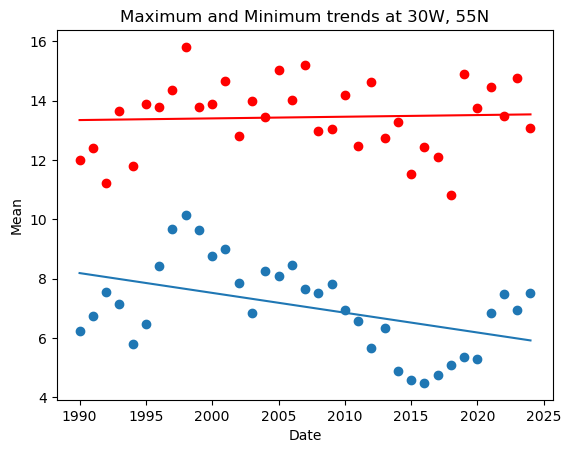

In [17]:
z_min = np.polyfit(min_temp['year'], min_temp.values, 1)
slope_min, intercept_min = z_min
min_line = slope_min * min_temp['year'] + intercept_min

z_max = np.polyfit(max_temp['year'], max_temp.values, 1)
slope_max, intercept_max = z_max
max_line = slope_max * max_temp['year'] + intercept_max

fig, ax = plt.subplots()
ax.scatter(min_temp['year'], min_temp.values)
ax.plot(min_temp['year'], min_line)
ax.set_xlabel('Date')
ax.set_ylabel('Mean')
ax.set_title('Maximum and Minimum trends at 30W, 55N')
ax.scatter(max_temp['year'], max_temp.values, color = 'r')
ax.plot(max_temp['year'], max_line, color = 'r')
print(f'minimum trend = {slope_min}')
print(f'maximum trend = {slope_max}')

In [ ]:
### Hudson Bay 

min_region = HB.sel(time_counter = HB['time_counter'].dt.month.isin([2, 3, 4]))
grouped = min_region.groupby('time_counter.year')
min_temp = (grouped.min(dim='time_counter')).compute()

max_region = HB.sel(time_counter = HB['time_counter'].dt.month.isin([8, 9, 10]))
grouped = max_region.groupby('time_counter.year')
max_temp = (grouped.max(dim ='time_counter')).compute()

minimum trend = -0.0003030825061958609
maximum trend = 0.07950355178501788


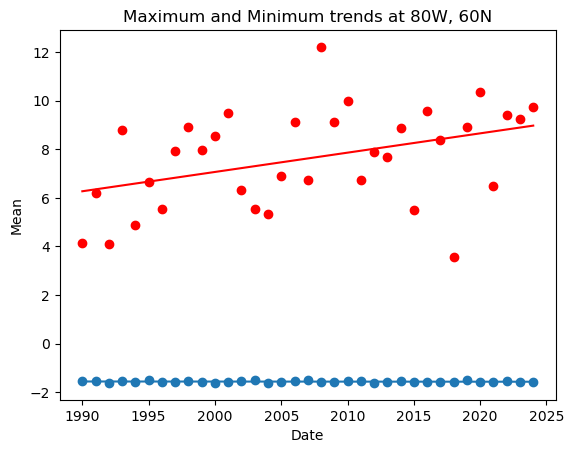

In [24]:
z_min = np.polyfit(min_temp['year'], min_temp.values, 1)
slope_min, intercept_min = z_min
min_line = slope_min * min_temp['year'] + intercept_min

z_max = np.polyfit(max_temp['year'], max_temp.values, 1)
slope_max, intercept_max = z_max
max_line = slope_max * max_temp['year'] + intercept_max

fig, ax = plt.subplots()
ax.scatter(min_temp['year'], min_temp.values)
ax.plot(min_temp['year'], min_line)
ax.set_xlabel('Date')
ax.set_ylabel('Mean')
ax.set_title('Maximum and Minimum trends at 80W, 60N')
ax.scatter(max_temp['year'], max_temp.values, color = 'r')
ax.plot(max_temp['year'], max_line, color = 'r')
print(f'minimum trend = {slope_min}')
print(f'maximum trend = {slope_max}')